# **1.서론**

1.1 분석 배경 및 목적 : 본 보고서는 정기적으로 헌혈에 참여하는 작성자의 개인적인 경험과 궁금중 "과연 다른 사람들은 헌혈을 자주 참여 하나?" 라는 의문을 가지고 작성하게 되었습니다.

In [9]:
import pandas as pd
from sklearn.datasets import fetch_openml

blood_data = fetch_openml(name='blood-transfusion-service-center', version=1, as_frame=True, parser='auto')

df = blood_data.frame

print("### Data Loaded Successfully! ###")
print(f"Dataset Shape: {df.shape}")
print("-" * 30)
df.head()

### Data Loaded Successfully! ###
Dataset Shape: (748, 5)
------------------------------


,V1,V2,V3,V4,Class
0,2,50,12500,98,2
1,0,13,3250,28,2
2,1,16,4000,35,2
3,2,20,5000,45,2
4,1,24,6000,77,1


1.2 데이터 셋 설명: 이 데이터는 대만의 헌혈 서비스 센터의 자료입니다.
                    **2006~2008**년 약 (20개월) / 인원 :**748**


*   V1 **최근성**      : 마지막 헌혈후 경과(시간)
*   V2 **회수**     : 총 헌혈 횟수
*   V3 **헌혈량**     : 헌혈한 전체 양
*   V4 **기간**      : 첫 헌혈 후 경과(시간)
*   Class **재방문**   : 재방문 의사 여부

1.3 가설 설정 : 총 헌혈 횟수가 많은 "다회 헌혈자"일수록, 미방문자/첫방문자보다 재방문할 확률이 높을것이다.

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

null_counts = df.isnull().sum()
print("### null count ###")
print(null_counts)

plt.figure(figsize=(10, 6))

sns.barplot(x=null_counts.index, y=null_counts.values, palette='rocket')

plt.title('Null Value Check (Bar Chart)', fontsize=15)
plt.xlabel('Columns')
plt.ylabel('Count of Nulls')
plt.ylim(0, 10)
plt.show()

# **2. 데이터 프로파일링**

2.2 결측치 분석: 결측치를 barplt로 나타낸 결과 본 데이터셋에는 결측치가 생기는 부분이 없었습니다.


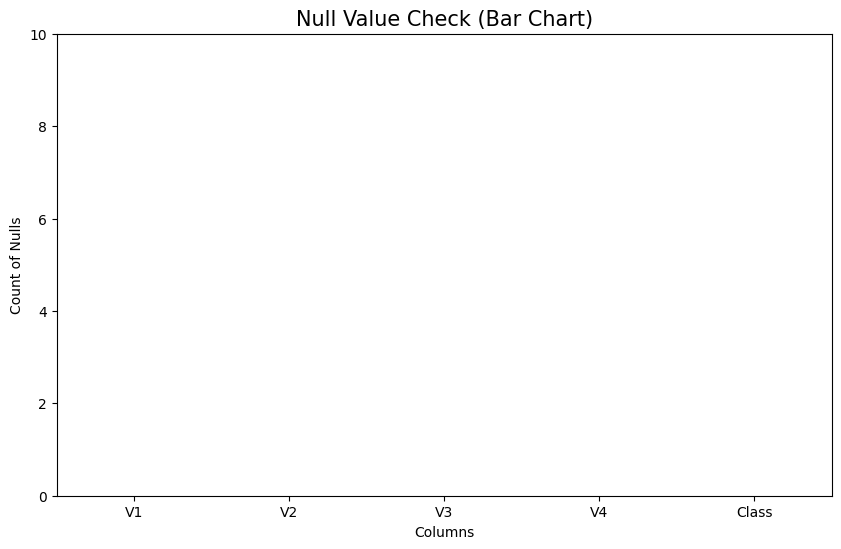

In [24]:
numeric_df = df.select_dtypes(include=['number'])

stats_df = numeric_df.describe().transpose()

stats_df['variance'] = numeric_df.var()

print("### 2.3 기초 통계량 분석 결과 (수치형 데이터) ###")
display(stats_df[['count', 'mean', 'std', 'variance', 'min', '25%', '50%', '75%', 'max']])

### 2.3 기초 통계량 분석 결과 (수치형 데이터) ###


,count,mean,std,variance,min,25%,50%,75%,max
V1,748.0,9.506684,8.095396,6.553543e+01,0.0,2.75,7.0,14.0,74.0
V2,748.0,5.514706,5.839307,3.409751e+01,1.0,2.00,4.0,7.0,50.0
V3,748.0,1378.676471,1459.826781,2.131094e+06,250.0,500.00,1000.0,1750.0,12500.0
V4,748.0,34.282086,24.376714,5.942242e+02,2.0,16.00,28.0,50.0,98.0


2.3 기초 통계량 분석

count(인원)
mean(평균)
std(표준편차)
var(분산)
min(최소값)
max(최대값)

가설과 연관 지은 내용
V2(횟수)를 보시면 75%인 이하 하지만 최대는 50으로 데이터가 분산됨 그 뜻은 최소에 정기헌혈자 인원들이 있다는 뜻 V2에 mean(평균)이 5.5이지만 중간값이 4.0인걸 보면 소수에 정기헌혈자들이 평균값을 올리고 있다는 뜻 즉 **"다회 헌혈자 일수록 재방문 확률이 높음"**걸 알 수 있습니다.

In [ ]:
initial_shape = df.shape
df = df.drop_duplicates()
final_shape = df.shape

import matplotlib.pyplot as plt
import seaborn as sns

##이상치
plt.figure(figsize=(12, 6))
sns.boxplot(data=df.select_dtypes(include=['number']), palette='Set2')
plt.title('Outlier Check (Box Plot)', fontsize=15)
plt.show()

In [31]:
print(f"현재 남은 데이터 개수: {len(df)}개")

현재 남은 데이터 개수: 533개


2.4 데이터 정제 결과

* 중복제거: 기존 데이터 **(748)** > 현 데이터 **(533)**
* 이상치 : 극소수에 **"다회헌혈자"** 인원들이 있다는 것을 보여준다.

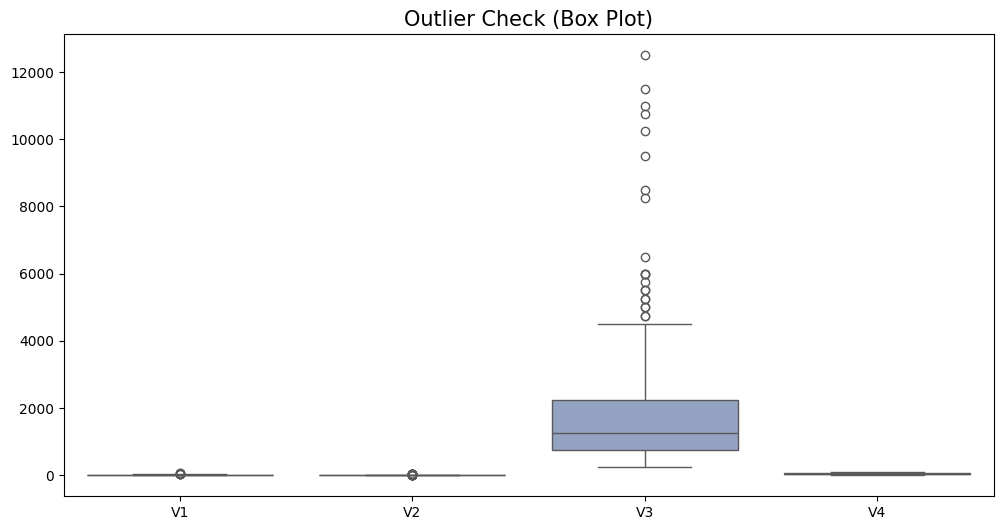

# **3.변수별 특성 분석**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis


numeric_cols = ['V1', 'V2', 'V3', 'V4']

for col in numeric_cols:
    s = skew(df[col])
    k = kurtosis(df[col])

    print(f"[{col}] 왜도: {s:.2f}, 첨도: {k:.2f}")

    plt.figure(figsize=(8, 4))

    sns.histplot(df[col], kde=True, color='indianred')
    plt.title(f'{col} Distribution (Skew: {s:.2f}, Kurt: {k:.2f})')
    plt.show()

3.1 수치형 변수 분석
(분포의 왜도와 첨도[히소토그램,kde])

*   왜도(꼬리) / 왜도:3.03
*   첨도(뾰족한 기둥) / 첨도:13.61

왜도값이 50까지 높게 나온다는 것은 소수의 "다회 헌혈자" 인원들이 있음을 말함

첨도값이 왼쪽으로 긴 이유는 다수의 인원이 0~10 사이에 횟수가 있다는 것을 말함



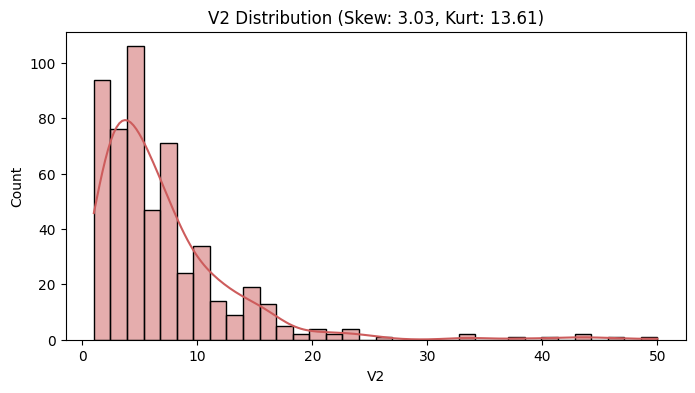

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

print("### 재방문 여부 빈도수 ###")
print(df['Class'].value_counts())

print("\n### 재방문 여부 비율 ###")
print(df['Class'].value_counts(normalize=True) * 100)

plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df, palette='Set2')

plt.title('Distribution of Re-visit (0: No, 1: Yes)', fontsize=15)
plt.xlabel('Re-visit Status')
plt.ylabel('Count')
plt.show()

3.2 범주형 분석
(클래스 비율 분석)

**재방문 여부(class)**

* x    384 (72%)
* o    149 (27%)

재방문 의사가 4분의1 정도의 수준으로, "다회 헌혈자" 인원들이 재방문 의사가 높다는 것을 확인 가능

희소 클래스: 특정이게 적은 클래스는 이 데이터에서는 발견 못함
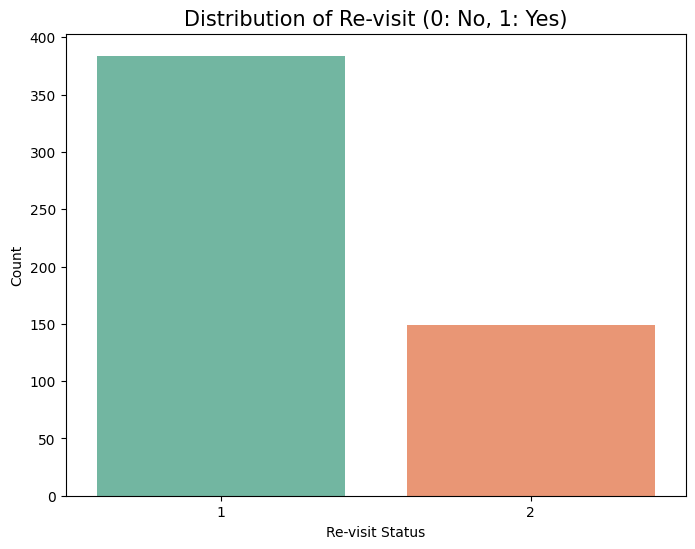


In [ ]:
bins = [0, 2, 10, df['V2'].max()]
labels = ['Beginner', 'Regular', 'Loyal']

df['V2_Level'] = pd.cut(df['V2'], bins=bins, labels=labels)

print("### 생성된 파생 변수(V2_Level) 빈도수 ###")
print(df['V2_Level'].value_counts())

plt.figure(figsize=(10, 6))
sns.countplot(x='V2_Level', data=df, hue='Class', palette='viridis')
plt.title('Re-visit Rate by Donation Level')
plt.show()

3.3 파생 변수 생성(재그룹화)

분석하기 좋은 자료로 재그룹

초보자 (reg) / 보통 (loy) / 정기적 (beg)

* Regular     336 (1~2)
* Loyal       103 (3~10)
* Beginner     94 (11~)

2008년 조사 기간으로 측정한거라 재방문 의사가 없는 인원들이 3회 이상에 헌혈을 한 결과가 있는 이유는 헌혈하고 나서의 휴식기간이나 개인사정 등으로 특정 시점에 대한 조사라 이런 값이 나왔다는걸 알 수 있음

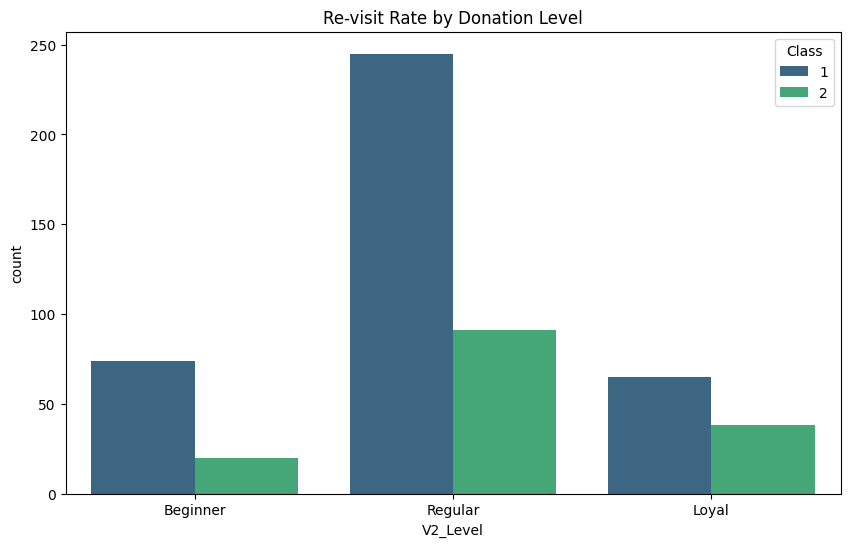

# **4. 상관관계 및 관계분석**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

if 'Class' in df.columns:
    df['Class'] = df['Class'].astype(int)

df_numeric = df.select_dtypes(include=['number'])

corr_matrix = df_numeric.corr()

print("### 숫자 변수 간 상관계수 (Class 기준) ###")
if 'Class' in corr_matrix.columns:
    print(corr_matrix['Class'].sort_values(ascending=False))

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
    plt.title('Final Correlation Heatmap')
    plt.show()
else:
    print("")

4.1 수치형 변숙 간 상관관계

가설과 연관지어서만 설명을 한다면 v2(횟수)와 class에 값이 0.17 양수 값이기에 헌혈횟수가 높아질수록 재방문 가능성이 같이 높아진다는 것을 알 수 있다.
그 반대인 경우 v1(기간)과 class에 값이 -0.27인 음수라는 것은 마지막으로 한 헌혈 기간이 길 수록 재방문 의사가 낮아진다는 것을 알 수 있다.

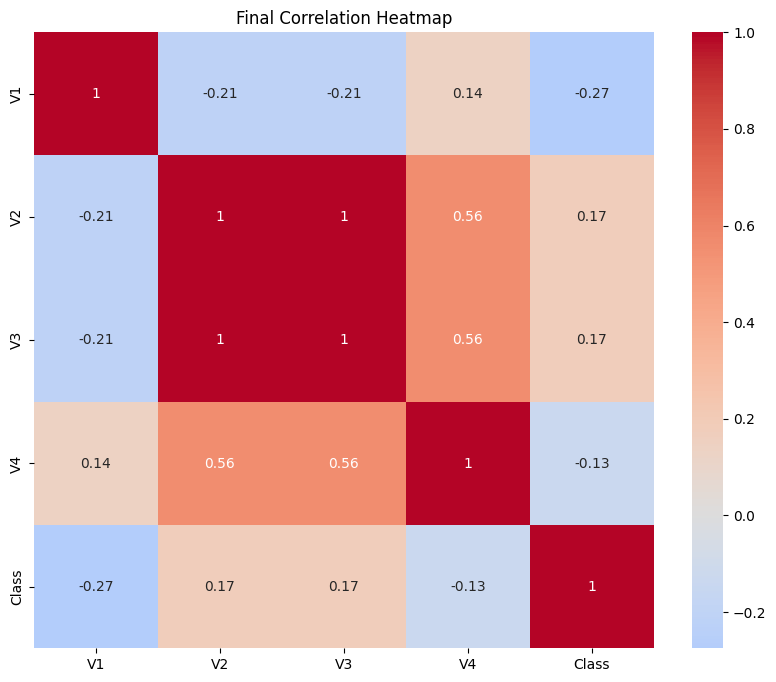

In [ ]:
df['Class_new'] = df['Class'].apply(lambda x: 1 if x == 2 else 0)

plt.figure(figsize=(10, 6))

sns.regplot(x='V2', y='Class_new', data=df, logistic=True, scatter_kws={'alpha':0.2}, line_kws={'color':'red'})
plt.title('Corrected Trend: Probability of Re-visit by V2')
plt.show()

4.1 산점도 및 추세선

파란색 점 : 산점도
빨간색 선 : 추세선

산점도 즉 데이터 위치들이 0~10 사이에 많이 몰린 것을 확인 가능함
추세선이 위로 올라가는 그래프로 나온다는 것은 우상향하는 그래프 즉 양수라는 것을 확인 가능함

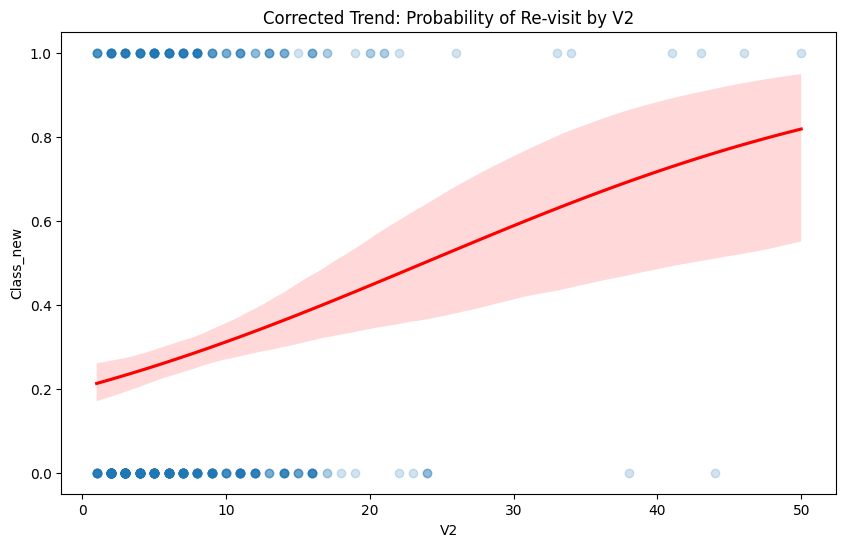

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.kdeplot(data=df, x='V2', hue='Class', fill=True, palette='Set1')

plt.title('Deep Dive: Distribution of V2 by Target(Class)', fontsize=15)
plt.xlabel('Total Number of Donations (V2)')
plt.ylabel('Density')
plt.show()

4.2 타겟 변수 및 심층 분석

class로 1 재방문 2 미방문 으로 나누어 과거 헌혈 횟수를 분석

* 1에 값이 0~10 사이에 있어 재방문한 인원들은 헌혈 횟수가 높다는 것을 알 수 있음
* 2에 값에는 0~10 사이인 왼쪽으로 기울어져 있음

이로서 헌혈 경험이 있는 자일수록 재방문 의사가 높다는 것을 알 수 있음



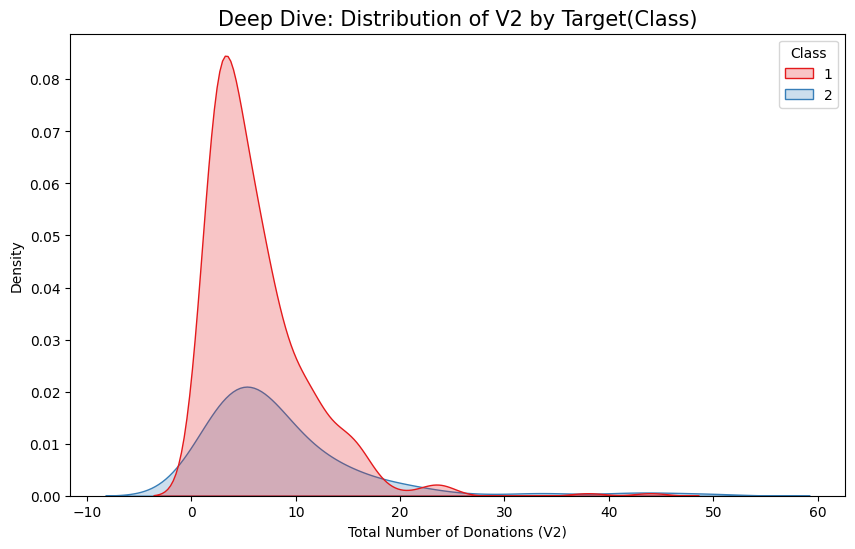

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

segment_pct = pd.crosstab(df['V2_Level'], df['Class'], normalize='index') * 100

segment_pct.plot(kind='bar', stacked=True, figsize=(10, 6), color=['#4CAF50', '#FF5252'])

plt.title('4.3 Re-visit Rate by Donation Level', fontsize=15)
plt.xlabel('Segment (Based on V2)')
plt.ylabel('Percentage (%)')
plt.legend(title='Re-visit', labels=['Yes (1)', 'No (2)'], loc='upper right')
plt.xticks(rotation=0)
plt.show()

print(segment_pct)

4.3 세그먼트별 비교 분석

특정조건에 따른 행동차이(헌혈을 많이 할 수록 재방문 비율 높은가)

3가지의 조건으로 다시 나누어 초보자,평균,정기적 으로 보았을때 측정한 달에는 오히려 헌혈에 경험이 적은 인원들이 재방문률이 높았으며, 경험이 많은 정기적인 분들이 재방문률이 적은걸 알 수 있음

그 이유로는 헌혈 주기로 인해 정기적인 인원들이 못 온 경우나 다른 이유로는 이 데이터를 수집한 달에만 일시적인 현상으로 볼 수 있음

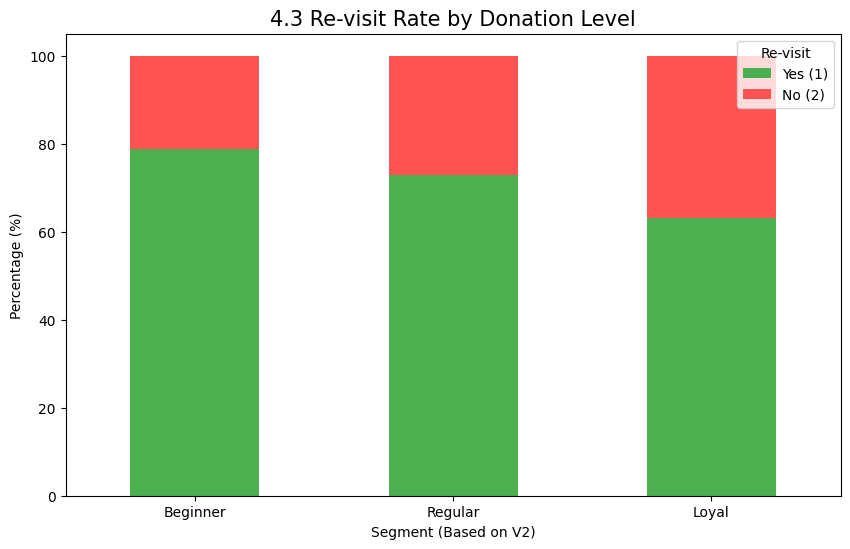

# **핵심 인사이트 및 가설 검정**

5.1 주요패턴

1.   헌혈자 분포 불규칙성: 대다수의 횟수가 초보자 (5회 미만) 정도에 머물고 있으며, 20회 이상의 헌혈자가 적다는 걸 알 수 있음
2.   단순히 헌혈횟수가 많다고 해서 재방문률이 압도적으로 높아지지 않다.
3.   측정 기간 기준 신규 헌혈자의 유입 인원들에 대한 재방문률이 높다는 것을 알 수 있다.



5.2 가설 검증 결과

앞서 가설로 **총 헌혈 횟수가 많은 "다회 헌혈자"일수록, 미방문자/첫방문자보다 재방문할 확률이 높을것이다.** 라는 검정결과는 다음과 같습니다.



1.   통계적 근거 : 4.1에 있던 상관계수에 값이 양수인 (0.17)인 것을 보아 어느정도에 확률이 높아질 수 있다는 것을 확인함
2.   심층 분석 : 4.2 그래프가 왼쪽이 아닌 오른쪽으로 가는 것으로 보아 정기적인 인원들이 있어 재방문에 확률이 꽤나 있다는 것을 확인함

0. 세그먼트 분석 : 4.3 그룹별로 나누어 비율을 확인하니 오히려 초보자 인원들에 재방문 확률이 80%, 정기적인 인원들이 63%로 반대인 결과가 나옴

**결론** : 1,2에 근거로 헌혈 횟수가 있을 수록 재방문 할 확률이 있다는 것을 확인 할 수 있지만, 3에 근거로 보았을대 횟수가 많다해서 재방문할 확률이 높지 않다는 것을 확인 할 수 있음


5.3 예상치 못한 결과


* 4.3에서 한 값에 따라 왜 그러한 결과가 나왔나 생각해보면 헌혈 주기의 영향이 크다고 생각합니다. 그 외에도 당시에 한 신규 유입에 대한 이벤트나 행사에 따른 영향도 생길 수 있다고 생각합니다.

# **결론 및 향후 방향**

6.1 분석 요약



1.   748명의 데이터로 V2(횟수)와 class(재방문 여부)를 가지고 분석함
2.   4.1/4.2를 통해 가설에 내용을 어느정도 뒷받침 했지만 4.3 세그먼트 분석으로 인해 초보자의 재방문 확률이 80%로 가장 높다는 것을 확인함
3.   장기적인 면에서는 과거의 헌혈 경험이 어느정도 중요하다는 것을 알 수 있지만, 단기적인 면에서는 신규 헌혈자의 참여 유도가 크다고 볼 수 있다.



6.2 비지니스 제언

가설에 내용이 이루어질려면 장기적인 헌혈자들을 위한 건강검진 서비스나 혜택과 같은 여러 서비스를 제공해야만 함

6.3 한계점 및 추후 과제



* 데이터의 한계 : 일단 데이터가 우리나라 아닌 대만이라 내가 원하는 데이터 값을 알 수 없으며, 데이터가 너무 오래전이라는 점도 크다고 생각함
* 예측 모델들을 도입하여 개인별 데이터를 가져와 수치화 할 수 있다 생각하며, 데이터 내용 말고도 그 이후에 데이터를 예측하는 방향으로도 해볼 수 있다고 생각합니다.
